In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


In [17]:
file_path = 'C:\\Users\\SHETU\\Desktop\\Shadow Fox\\car.csv'
df = pd.read_csv(file_path)

In [18]:
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

First 5 rows of the dataset:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non

In [19]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [20]:
df.dropna(inplace=True)

In [21]:
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)



Duplicate Rows: 2


In [22]:
df['Kms_Driven'] = pd.to_numeric(df['Kms_Driven'], errors='coerce')
df.dropna(inplace=True)

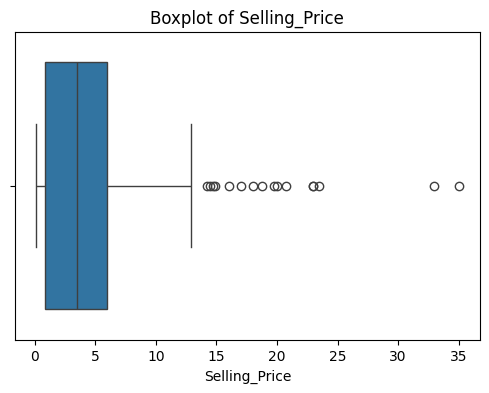

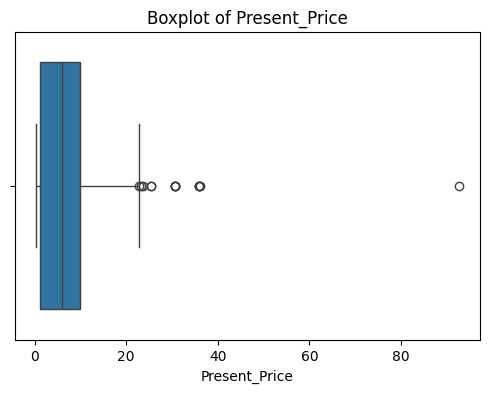

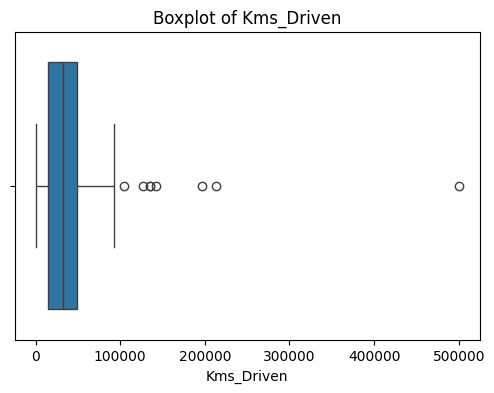

In [23]:
numerical_columns = ['Selling_Price', 'Present_Price', 'Kms_Driven']
for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [24]:
df['Car_Age'] = 2025 - df['Year']

In [25]:
df.drop(['Year'], axis=1, inplace=True)

In [26]:
print("\nUpdated Dataset:")
print(df.head())


Updated Dataset:
  Car_Name  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0     ritz           3.35           5.59       27000    Petrol      Dealer   
1      sx4           4.75           9.54       43000    Diesel      Dealer   
2     ciaz           7.25           9.85        6900    Petrol      Dealer   
3  wagon r           2.85           4.15        5200    Petrol      Dealer   
4    swift           4.60           6.87       42450    Diesel      Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       11  
1       Manual      0       12  
2       Manual      0        8  
3       Manual      0       14  
4       Manual      0       11  


In [27]:
categorical_columns = ['Fuel_Type', 'Seller_Type', 'Transmission']
numerical_columns = ['Car_Age', 'Present_Price', 'Kms_Driven', 'Owner']

In [28]:
X = df[categorical_columns + numerical_columns]
y = df['Selling_Price']

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ])

In [30]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Car_Age', 'Present_Price',
                                                   'Kms_Driven', 'Owner']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [33]:
y_pred = pipeline.predict(X_test)

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")


Model Performance:
Mean Absolute Error (MAE): 1.4070850000000013
Mean Squared Error (MSE): 11.000892905833345
Root Mean Squared Error (RMSE): 3.3167593982430117
R² Score: 0.5731664540180654


In [36]:
joblib.dump(pipeline, 'car_price_model.pkl')
print("\nModel saved as 'car_price_model.pkl'")



Model saved as 'car_price_model.pkl'


In [37]:
new_car = pd.DataFrame({
    'Fuel_Type': ['Petrol'],
    'Seller_Type': ['Individual'],
    'Transmission': ['Manual'],
    'Car_Age': [5],
    'Present_Price': [7.5],  # in lakhs
    'Kms_Driven': [40000],
    'Owner': [1]
})

predicted_price = pipeline.predict(new_car)
print(f"The predicted selling price of the car is: {predicted_price[0]:.2f} lakhs")


The predicted selling price of the car is: 5.49 lakhs
